Num documents: 4601
Num documents after filtering short ones: 4560
Vocabulary size: 1437
Training LDA with K=1
K=1, coherence=0.4134
Training LDA with K=2
K=2, coherence=0.3892
Training LDA with K=3
K=3, coherence=0.4065
Training LDA with K=4
K=4, coherence=0.4192
Training LDA with K=5
K=5, coherence=0.3919
Training LDA with K=6
K=6, coherence=0.3776
Training LDA with K=7
K=7, coherence=0.3884
Training LDA with K=8
K=8, coherence=0.4000
Training LDA with K=9
K=9, coherence=0.3836
Training LDA with K=10
K=10, coherence=0.3826


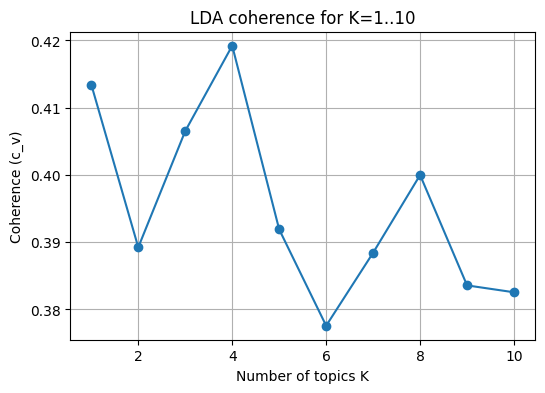

Best K by coherence: 4 (coherence=0.4192)
Topic 0: i, the, you, to, not, it, t, that, m, s
Topic 1: to, a, my, the, for, is, not, you, of, on
Topic 2: the, to, a, is, and, can, s, in, it, that
Topic 3: the, a, in, and, of, i, is, that, s, not


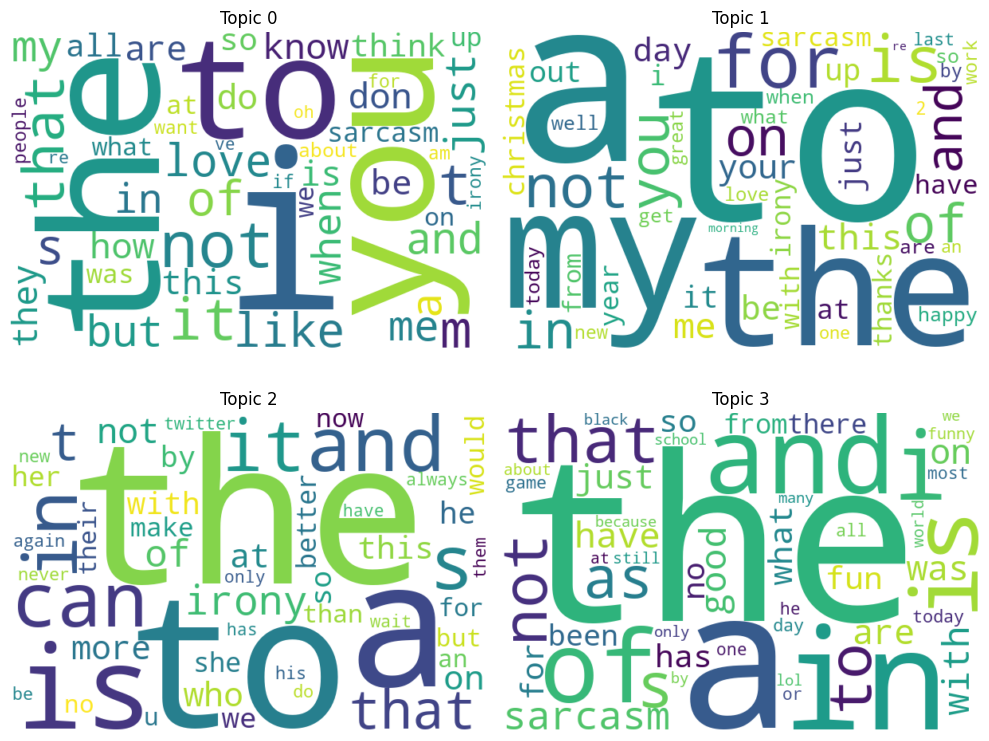

In [1]:
# Task 2: Topic Modeling with LDA + coherence + word clouds
# (Code skeleton written with help from Perplexity, and some manual adjustments)

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import gensim
from gensim import corpora
from gensim.models import CoherenceModel, LdaModel

from wordcloud import WordCloud
from tqdm import tqdm

# 1) Load data -------------------------------------------------------------

with open("data_asg1.txt", encoding="utf-8") as f:
    texts_raw = [line.strip() for line in f.readlines()]

print("Num documents:", len(texts_raw))  # should be 4601

# 2) Simple tweet preprocessing -------------------------------------------

def clean_tweet(text):
    text = text.lower()
    text = re.sub(r"http\S+", " ", text)      # URLs
    text = re.sub(r"@\w+", " ", text)        # @user
    text = re.sub(r"#", " ", text)           # remove # but keep word
    text = re.sub(r"[^a-z0-9\s]", " ", text) # keep only letters/numbers/spaces
    text = re.sub(r"\s+", " ", text).strip()
    return text

docs_clean = [clean_tweet(t) for t in texts_raw]

# tokenize
tokenized_docs = [doc.split() for doc in docs_clean]

# remove very short docs
tokenized_docs = [doc for doc in tokenized_docs if len(doc) > 2]

print("Num documents after filtering short ones:", len(tokenized_docs))

# 3) Build dictionary and corpus ------------------------------------------

dictionary = corpora.Dictionary(tokenized_docs)
# optional: filter very rare and very frequent words
dictionary.filter_extremes(no_below=5, no_above=0.5)
dictionary.compactify()

corpus = [dictionary.doc2bow(doc) for doc in tokenized_docs]

print("Vocabulary size:", len(dictionary))

# 4) Train LDA for K = 1..10 and compute coherence ------------------------

coherence_scores = {}
lda_models = {}

for k in range(1, 11):
    print(f"Training LDA with K={k}")
    lda = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        random_state=42,
        passes=10,
        alpha='symmetric',  # roughly alpha = 1
        eta='symmetric'     # roughly beta = 1
    )
    lda_models[k] = lda

    cm = CoherenceModel(
        model=lda,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence='c_v'
    )
    coherence = cm.get_coherence()
    coherence_scores[k] = coherence
    print(f"K={k}, coherence={coherence:.4f}")

# plot coherence vs K
plt.figure(figsize=(6,4))
plt.plot(list(coherence_scores.keys()), list(coherence_scores.values()), marker="o")
plt.xlabel("Number of topics K")
plt.ylabel("Coherence (c_v)")
plt.title("LDA coherence for K=1..10")
plt.grid(True)
plt.show()

# 5) Select best K (highest coherence) ------------------------------------

best_k = max(coherence_scores, key=coherence_scores.get)
best_coh = coherence_scores[best_k]
print(f"Best K by coherence: {best_k} (coherence={best_coh:.4f})")

best_lda = lda_models[best_k]

# 6) Show top words per topic for best K ----------------------------------

def print_top_words(lda_model, num_words=10):
    for topic_id in range(lda_model.num_topics):
        terms = lda_model.show_topic(topic_id, topn=num_words)
        terms_str = ", ".join([w for w, p in terms])
        print(f"Topic {topic_id}: {terms_str}")

print_top_words(best_lda, num_words=10)

# 7) Generate word clouds for each topic ----------------------------------

fig, axes = plt.subplots(
    nrows=int(np.ceil(best_k / 2)),
    ncols=2,
    figsize=(10, 4 * int(np.ceil(best_k / 2)))
)
axes = axes.flatten()

for topic_id in range(best_k):
    terms = best_lda.show_topic(topic_id, topn=50)
    freqs = {w: float(p) for w, p in terms}
    wc = WordCloud(
        width=600,
        height=400,
        background_color="white"
    ).generate_from_frequencies(freqs)

    ax = axes[topic_id]
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"Topic {topic_id}")

# hide any unused subplots
for j in range(best_k, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()
